# Different isoforms

In [ ]:
library(tidyverse)
library(vroom)
library(data.table)
library(pheatmap)
library(preprocessCore)
library(purrr)
library(RColorBrewer)
library(ggpubr)

reverse_complement <- function(dna_seq) {
  complement <- c("A" = "T", "T" = "A", "C" = "G", "G" = "C")
  nucleotides <- unlist(strsplit(dna_seq, ""))
  complement_nucleotides <- complement[nucleotides]
  reverse_complement_seq <- paste(rev(complement_nucleotides), collapse = "")
  return(reverse_complement_seq)
}


output_filepath <- "/mnt/dawnccle2/melange/figures_outputs/figS02"
# Create the output directory if it doesn't exist.
if (!dir.exists(output_filepath)) {
  dir.create(output_filepath, recursive = TRUE)
}

all_files_df_path <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_raw_counts.csv"
all_files_df <- fread(all_files_df_path)

# > head(all_files_df)
# index
# 
# 1: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 2: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 3: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 4: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 5: ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252
# 6: ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252
# mode offset count count_scaled    sample condition
#                   
# 1:  INCLUDED 0:-1:0     1            1 769P-rep1      769P
# 2:  INCLUDED  0:0:0    29           29 769P-rep1      769P
# 3:   SKIPPED      0     3            0 769P-rep1      769P
# 4: UNSPLICED    113     3            0 769P-rep1      769P
# 5:  INCLUDED  0:0:0    88           88 769P-rep1      769P
# 6:   SKIPPED      0    15            1 769P-rep1      769P


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘vroom’


The following objects are masked from ‘package:readr’:

    as.col_spec, col_character, col_date, col_datetime, col_double,
    col_factor, col_guess, col_integer, col_logical, col_number,
    col_skip, col_time, cols, cols_condense, cols_only, date_names,
    date_names_lang, date_names_langs, default_locale, fwf_cols,
    fwf_empty, fwf_positions, fwf_widths, locale, output_column,
    problems, spec



Attaching package: ‘data.table’


The

# Compute included percentage

In [ ]:
all_files_df_filtered <- all_files_df %>% 
  filter(!(condition %in% c("K562WT", "K562K700E"))) %>% 
  filter(!(condition %in% c("JHOM1", "RVH421", "KNS60", "OVTOKO"))) %>% 
  group_by(sample, index) %>% 
  mutate(total_count = sum(count_scaled)) %>% 
  filter(total_count >= 30) 

# Compute included percentage
included_only <- all_files_df_filtered %>%
  filter(mode == "INCLUDED") %>%
  group_by(sample, index) %>% 
  mutate(total_included  = sum(count_scaled)) %>%
  filter(total_included >= 30) %>% 
  ungroup() %>%
  mutate(included_perc = count_scaled / total_included) 

included_only <- included_only %>% 
  separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":", remove = F) %>% 
  mutate(upstream_offset = as.integer(upstream_offset),
         downstream_offset = as.integer(downstream_offset)) %>%
  filter(abs(upstream_offset) != 1) %>% 
  filter(abs(downstream_offset) != 1) 

# Get how many included reads are there per index per sample. 
num_included_events_per_sample <- included_only %>% 
  group_by(sample, index) %>% 
  summarise(num_included_events = n_distinct(offset))

num_included_events_per_sample_wide <- num_included_events_per_sample %>% 
  pivot_wider(names_from = sample, values_from = num_included_events)

included_by_condition <- included_only %>% 
  group_by(condition, index, offset, upstream_offset, downstream_offset, const_offset) %>% 
  summarise(included_perc = mean(included_perc, na.rm = T), n= n()) %>%
  filter(n >= 2)

`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'condition', 'index', 'offset',
'upstream_offset', 'downstream_offset'. You can override using the `.groups`
argument.


# Get number of splice sites per index

In [ ]:
num_splice_sites_per_index <- included_by_condition %>% 
  group_by(index, offset) %>%
  mutate(num_occurances = n()) %>%
  filter(num_occurances >= 22) %>%
  ungroup() %>% 
  group_by(index) %>%
  summarise(num_splice_sites = n_distinct(offset))

p1 <- ggplot(num_splice_sites_per_index, aes(x = num_splice_sites)) +
  geom_histogram(binwidth = 1, fill = "#80AED1", color = "black") +  # High contrast bars
  scale_x_continuous(breaks = seq(min(num_splice_sites_per_index$num_splice_sites), 
                                  max(num_splice_sites_per_index$num_splice_sites), by = 1)) +  # Ensure integer ticks
  labs(title = "Distribution of Number of Splice Sites per Index",
       x = "Number of Alternative 3'ss",
       y = "Frequency") +
  theme_classic(base_size = 16) +  # Remove grid lines, improve readability
  theme(
    axis.text.x = element_text(size = 14),  # Readable x-axis
    axis.text.y = element_text(size = 14),  # Readable y-axis
    axis.title = element_text(size = 16),   # Readable axis titles
    plot.title = element_text(size = 18, hjust = 0.5),  # Centered title
    panel.grid.minor = element_blank()  # Remove minor grid lines
  )

ggsave(filename = paste0(output_filepath, "/figS02_num_splice_sites_per_index.pdf"),
       plot = p1,
       width = 600, height = 500, units = "px", dpi = 150)

In [ ]:
# Get how many sequences have more than 1 splice site

seq_with_multiple_splice_sites <- num_splice_sites_per_index %>% 
    filter(num_splice_sites > 1) %>% 
    nrow()

print(paste0("Number of sequences with more than 1 splice site: ", seq_with_multiple_splice_sites))
# Proportion of sequences with more than 1 splice site
prop_seq_with_multiple_splice_sites <- seq_with_multiple_splice_sites / nrow(num_splice_sites_per_index)
print(paste0("Proportion of sequences with more than 1 splice site: ", prop_seq_with_multiple_splice_sites))

# Get how many sequences have more than 2 splice sites
seq_with_multiple_splice_sites <- num_splice_sites_per_index %>% 
    filter(num_splice_sites > 2) %>% 
    nrow()

print(paste0("Number of sequences with more than 2 splice site: ", seq_with_multiple_splice_sites))

[1] "Number of sequences with more than 1 splice site: 10104"
[1] "Proportion of sequences with more than 1 splice site: 0.311361745400758"
[1] "Number of sequences with more than 2 splice site: 2093"


## Plot a heatmap of the top 4 sequences with the most number of alternative splice sites detected

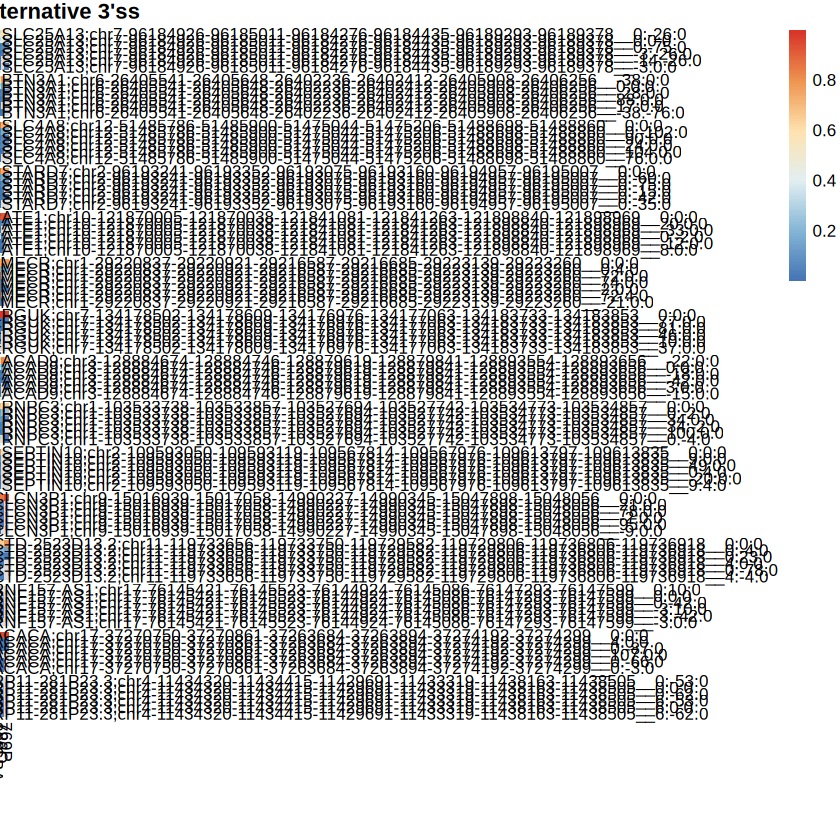

In [ ]:
top_5_sequences <- num_splice_sites_per_index %>%
  top_n(2, num_splice_sites) %>%
  pull(index)

# Prepare data
included_only_filtered <- included_by_condition %>%
  ungroup() %>% 
  filter(index %in% top_5_sequences) %>%  
  mutate(index_offset = paste(index, offset, sep = "__")) %>%
  select(index_offset, condition, included_perc) %>% 
  pivot_wider(names_from = condition, values_from = included_perc) 

# Order rows by descending mean value
included_only_filtered <- included_only_filtered %>%
  mutate(row_mean = rowMeans(select(., -index_offset), na.rm = TRUE)) %>%
  mutate(index = sapply(strsplit(index_offset, "__"), `[`, 1)) %>%
  arrange(index, desc(row_mean)) %>%
  select(-row_mean, -index)

# Filter rows that have < 50% missing values
included_only_filtered <- included_only_filtered %>%
  filter(rowMeans(is.na(included_only_filtered[, -1])) < 0.5)

# Convert to matrix
mat <- as.matrix(included_only_filtered[, -1])
rownames(mat) <- included_only_filtered$index_offset

# Identify row indices for adding a gap
index_labels <- included_only_filtered$index_offset
sequence_labels <- sapply(strsplit(index_labels, "__"), `[`, 1)  # Extract sequence ID
sequence_change_points <- which(diff(as.numeric(factor(sequence_labels))) != 0)  # Find index where sequence changes

# Define colors
color_palette2 <- c(
  "#4575B4",  # deep blue
  "#85B6D6",  # slightly lighter/more even blue
  "#E2EFF2",  # less stark pastel blue
  "#FFE3B0",  # warmer, slightly less saturated yellow
  "#EF9651",  # softer orange
  "#D83629"   # red
)
color_palette2_custom <- colorRampPalette(color_palette2)(100)
color_palette2_custom_rev <- colorRampPalette(rev(color_palette2))(100)

# Save heatmap as high-resolution PDF
p3 <- pheatmap(mat,
         cluster_rows = FALSE,  # Maintain alphabetical ordering
         cluster_cols = F,   # Cluster samples (columns)
         show_rownames = TRUE,
         show_colnames = TRUE,
         color = color_palette2_custom,
         main = "Top 2 Sequences with Most Alternative 3'ss",
         fontsize_row = 10,  # Readable row labels
         fontsize_col = 10,
         gaps_row = sequence_change_points)  # Add divider between the two sequences

ggsave(filename = paste0(output_filepath, "/figS02_top_2_sequences_heatmap.pdf"),
       plot = p3,
       width = 24, height = 16, dpi = 300)


In [ ]:
# What about detected sequences across all samples
num_splice_sites_per_index <- included_by_condition %>% 
  group_by(index, offset) %>%
  mutate(num_occurances = n()) %>%
  ungroup() %>% 
  group_by(index) %>%
  summarise(num_splice_sites = n_distinct(offset)) %>%
  mutate(num_splice_sites = ifelse(num_splice_sites >= 10, 10, num_splice_sites))

p2 <- ggplot(num_splice_sites_per_index, aes(x = num_splice_sites)) +
  geom_histogram(binwidth = 1, fill = "#80AED1", color = "black") +  # High contrast bars
  scale_x_continuous(breaks = seq(min(num_splice_sites_per_index$num_splice_sites), 
                                max(num_splice_sites_per_index$num_splice_sites), by = 1),
                    labels = function(x) ifelse(x == 10, ">=10", as.character(x))) +  # Custom labels
  labs(title = "Distribution of Number of Splice Sites per Index",
       x = "Number of Alternative 3'ss",
       y = "Frequency") +
  theme_classic(base_size = 16) +  # Remove grid lines, improve readability
  theme(
    axis.text.x = element_text(size = 14),  # Readable x-axis
    axis.text.y = element_text(size = 14),  # Readable y-axis
    axis.title = element_text(size = 16),   # Readable axis titles
    plot.title = element_text(size = 18, hjust = 0.5),  # Centered title
    panel.grid.minor = element_blank()  # Remove minor grid lines
  )

ggsave(filename = paste0(output_filepath, "/figS02_num_splice_sites_per_index_all_sites.pdf"),
       plot = p2,
       width = 600, height = 500, units = "px", dpi = 150)

# Get how many sequences have more than 1 splice site

seq_with_multiple_splice_sites <- num_splice_sites_per_index %>% 
    filter(num_splice_sites > 1) %>% 
    nrow()

print(paste0("Number of sequences with more than 1 splice site: ", seq_with_multiple_splice_sites))
# Proportion of sequences with more than 1 splice site
prop_seq_with_multiple_splice_sites <- seq_with_multiple_splice_sites / nrow(num_splice_sites_per_index)
print(paste0("Proportion of sequences with more than 1 splice site: ", prop_seq_with_multiple_splice_sites))

# Get how many sequences have more than 2 splice sites
seq_with_multiple_splice_sites <- num_splice_sites_per_index %>% 
    filter(num_splice_sites > 2) %>% 
    nrow()

print(paste0("Number of sequences with more than 2 splice site: ", seq_with_multiple_splice_sites))

[1] "Number of sequences with more than 1 splice site: 34120"
[1] "Proportion of sequences with more than 1 splice site: 0.866935996137917"
[1] "Number of sequences with more than 2 splice site: 26554"


# Get the major splice site per sequence

In [ ]:
# Major splice site

major_splice_site <- included_by_condition %>% 
  group_by(index, offset) %>% 
  summarise(average_perc = mean(included_perc, na.rm = T)) %>% 
  ungroup() %>% 
  arrange(desc(average_perc)) %>% 
  group_by(index) %>% 
  slice(1)

`summarise()` has grouped output by 'index'. You can override using the
`.groups` argument.


In [ ]:
# Get how many sequences have more than 1 splice site

seq_with_multiple_splice_sites <- num_splice_sites_per_index %>% 
    filter(num_splice_sites > 1) %>% 
    nrow()

print(paste0("Number of sequences with more than 1 splice site: ", seq_with_multiple_splice_sites))
# Proportion of sequences with more than 1 splice site
prop_seq_with_multiple_splice_sites <- seq_with_multiple_splice_sites / nrow(num_splice_sites_per_index)
print(paste0("Proportion of sequences with more than 1 splice site: ", prop_seq_with_multiple_splice_sites))

# Get how many sequences have more than 2 splice sites
seq_with_multiple_splice_sites <- num_splice_sites_per_index %>% 
    filter(num_splice_sites > 2) %>% 
    nrow()

print(paste0("Number of sequences with more than 2 splice site: ", seq_with_multiple_splice_sites))

[1] "Number of sequences with more than 1 splice site: 34120"
[1] "Proportion of sequences with more than 1 splice site: 0.866935996137917"
[1] "Number of sequences with more than 2 splice site: 26554"


In [ ]:
# Get how many of the splice sites are not 0:0:0

num_not_000 <- major_splice_site %>% 
  filter(offset != "0:0:0") %>% 
  nrow()

num_000 <- major_splice_site %>% 
  filter(offset == "0:0:0") %>% 
  nrow()

print(paste0("Number of splice sites not 0:0:0: ", num_not_000))
print(paste0("Number of splice sites 0:0:0: ", num_000))

# Percentage of splice sites that are not 0:0:0
percentage_not_000 <- num_not_000 / (num_not_000 + num_000)
print(paste0("Percentage of splice sites that are not 0:0:0: ", percentage_not_000))

# Percentage of splice sites that are 0:0:0
percentage_000 <- num_000 / (num_not_000 + num_000)
print(paste0("Percentage of splice sites that are 0:0:0: ", percentage_000))

[1] "Number of splice sites not 0:0:0: 1787"
[1] "Number of splice sites 0:0:0: 37570"
[1] "Percentage of splice sites that are not 0:0:0: 0.0454048835022995"
[1] "Percentage of splice sites that are 0:0:0: 0.954595116497701"


# Look at whether the splice donor and splice acceptor has more differences

In [ ]:
consistent_splice_sites <- num_splice_sites_per_index <- included_by_condition %>% 
  group_by(index, offset) %>%
  mutate(num_occurances = n()) %>%
  filter(num_occurances >= 22) %>%
  ungroup()

# Get percentage of rows where upstream_offset != 0 and downstream_offset != 0

upstream_offset_not_0 <- consistent_splice_sites %>% 
  filter(upstream_offset != 0) %>% 
  nrow()

downstream_offset_not_0 <- consistent_splice_sites %>% 
  filter(downstream_offset != 0) %>% 
  nrow()

print(paste0("Percentage of rows where upstream_offset != 0: ", upstream_offset_not_0 / nrow(consistent_splice_sites)))
print(paste0("Percentage of rows where downstream_offset != 0: ", downstream_offset_not_0 / nrow(consistent_splice_sites)))

# Get percentage of rows where upstream_offset != 0 and downstream_offset != 0

upstream_offset_not_0_and_downstream_offset_not_0 <- consistent_splice_sites %>% 
  filter(upstream_offset != 0 & downstream_offset != 0) %>% 
  nrow()

print(paste0("Percentage of rows where upstream_offset != 0 and downstream_offset != 0: ", upstream_offset_not_0_and_downstream_offset_not_0 / nrow(consistent_splice_sites)))

[1] "Percentage of rows where upstream_offset != 0: 0.166159494388252"
[1] "Percentage of rows where downstream_offset != 0: 0.0978974497066379"
[1] "Percentage of rows where upstream_offset != 0 and downstream_offset != 0: 0.00768649067876605"


# Look at the "unspliced reads" (or reads that have splicing in the constant intronic sequence)

In [ ]:
# Extract all possible (index, sample, offset) combinations
all_distinct_sample <- unique(all_files_df_filtered$sample)

all_distinct_offsets <- unique(all_files_df_filtered$offset)

all_distinct_index <- unique(all_files_df_filtered$index)

num_unique_index_per_sample <- all_files_df_filtered %>% 
  group_by(sample) %>% 
  summarise(num_unique_index = n_distinct(index))

# Compute unspliced percentage
unspliced_only <- all_files_df_filtered %>%
  filter(mode == "UNSPLICED") %>%
  mutate(unspliced_perc = count_scaled / total_count) %>% 
  left_join(num_unique_index_per_sample, by = "sample") 

unspliced_by_sample <- unspliced_only %>% 
  ungroup() %>% 
  group_by(sample, offset) %>% 
  summarise(mean_unspliced_perc = sum(unspliced_perc)/ num_unique_index[1]) 
  

##############################################################
##### General Heatmap Plot ###################################
##############################################################
unspliced_by_sample_pivot <- unspliced_by_sample %>% 
  pivot_wider(names_from = offset, values_from = mean_unspliced_perc, values_fill = 0) %>%
  relocate(order(as.integer(names(.)[-1])))  # Reorder offset columns numerically

# Define complete numeric column range
full_columns <- as.character(0:152)

# Add missing columns with 0s
missing_cols <- setdiff(full_columns, colnames(unspliced_by_sample_pivot))
unspliced_by_sample_pivot[missing_cols] <- 0

# Average across conditions
unspliced_by_condition_pivot <- unspliced_by_sample_pivot %>%
  mutate(condition = str_extract(sample, ".*(?=-rep)")) %>%
  group_by(condition) %>%
  summarise(across(all_of(full_columns), \(x) mean(x, na.rm = TRUE))) %>%
  ungroup()

# Reorder columns numerically
offsets_numeric <- as.integer(names(unspliced_by_condition_pivot)[-1])
sorted_order <- order(offsets_numeric) + 1  # +1 to account for "sample" column
unspliced_by_condition_pivot <- unspliced_by_condition_pivot[, c(1, sorted_order)]  

# Convert to matrix
unspliced_mat <- as.matrix(unspliced_by_condition_pivot[, -1])  
rownames(unspliced_mat) <- unspliced_by_condition_pivot$condition  


`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.


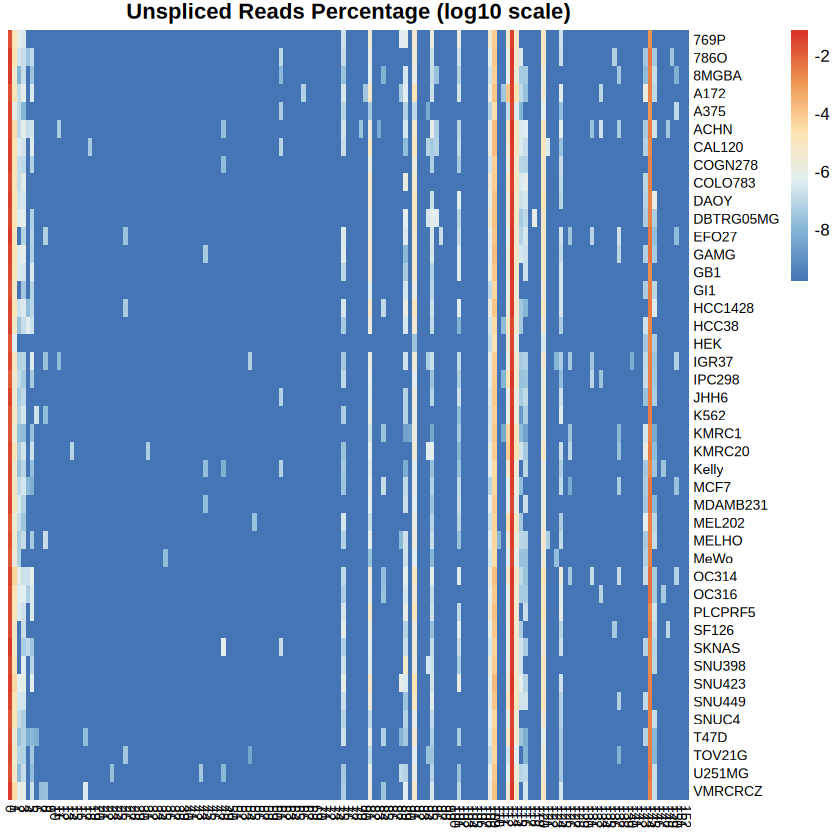

In [ ]:
# Save heatmap to high-resolution PDF
# Handle zeros before taking log10 by adding small constant
unspliced_mat_adj <- unspliced_mat
unspliced_mat_adj[unspliced_mat_adj == 0] <- min(unspliced_mat[unspliced_mat > 0])/10

p4 <- pheatmap(log10(unspliced_mat_adj), 
         cluster_rows = FALSE, 
         cluster_cols = FALSE, 
         show_rownames = TRUE, 
         show_colnames = TRUE,
         main = "Unspliced Reads Percentage (log10 scale)",
         fontsize_row = 8,   # Increase for readability
         fontsize_col = 8,   # Increase for clarity
         color = color_palette2_custom)

ggsave(filename = paste0(output_filepath, "/figS02_splicing_in_constant_intron_reads_heatmap.pdf"),
       plot = p4,
       width = 24, height = 16, dpi = 300)

# Plot a bar plot of the base that's right at the splice acceptor

Need to have at least 1e-8 % to be considered ok

In [ ]:
# Plot a bar plot.
seq <- "GTGAAGTGATGATGATGGCTGACCAGGCGTTACAGTGTCTCTAGGCAGTTGCTGGGAACTGGCTAGAGACATAAGGTTAAGATGTGAGGAGATGGGTTTTGATTTCTGGACAGGGGAAAGGAAGTAATCTGAGATTGAATCCAGGAAATGAA"
# Convert sequence into individual characters
seq_bases <- unlist(strsplit(seq, ""))
unspliced_grouped <- unspliced_by_sample %>%
  group_by(offset) %>%
  summarise(mean_unspliced_perc = mean(mean_unspliced_perc, na.rm = TRUE)) %>%
  ungroup() %>%
  mutate(
    offset = as.integer(offset),  # Ensure numeric ordering
    base = ifelse(offset > 0 & offset <= length(seq_bases), seq_bases[offset], NA)  # Map bases
  ) %>% 
  filter(mean_unspliced_perc > 1e-8) %>%   # Filter out rows with mean_unspliced_perc == 0
  filter(offset >= 30)


num_per_base <- unspliced_grouped %>% group_by(base) %>% 
  summarise(n = n()) %>% 
  # Add a row for each base with n = 0
  complete(base = c("A", "C", "G", "T"), fill = list(n = 0)) 
p1 <- ggplot(num_per_base, aes(x = base, y = n)) +
  geom_bar(stat = "identity", fill = "#80AED1", color = "black", width = 0.8) +  # Adjust bar width
  labs(title = "Number of Bases per Position",
       x = "Base",
       y = "Count") +
  theme_classic(base_size = 16) +  # Remove grid lines, increase font size
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 14),  # Rotate x-axis labels
    axis.text.y = element_text(size = 14),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 18, hjust = 0.5),  # Center title
    panel.grid.minor = element_blank()  # Remove minor grid lines
  )

ggsave(file.path(output_filepath, "figS02_number_of_bases_per_position.pdf"), plot = p1,
       width = 6, height = 4, dpi = 300)  


# Plot the sequence logos of both canonical vs non-canonical splice sites

In [ ]:
final_psi_table_filtered <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table.csv")
final_psi_table_filtered <- final_psi_table_filtered %>% 
  filter(!(condition %in% c("K562WT", "K562K700E"))) %>% 
  filter(!(condition %in% c("JHOM1", "RVH421", "KNS60", "OVTOKO"))) %>% 
  mutate(total_count = included_count + skipped_count) %>%
  filter(total_count >= 30) %>%
  mutate(index_offset = paste(index, offset, sep = "__")) %>% 
  separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":") %>% 
  mutate(upstream_offset = as.integer(upstream_offset)) %>% 
  mutate(downstream_offset = as.integer(downstream_offset)) %>%
  mutate(const_offset = as.integer(const_offset)) %>% 
  filter(abs(upstream_offset) != 1 & abs(downstream_offset)!= 1) %>% 
  dplyr::select(-upstream_offset, -downstream_offset, -const_offset) %>% 
  dplyr::select(-index, -mode) %>%
  mutate(PSI = included_count/(included_count + skipped_count))
# Filter out the sequences that are in the blacklist.
blacklist_sequences <- read.csv("/mnt/dawnccle2/melange/process_fastq_250221/03_convert_to_PSI/WT_all_samples_blacklist_sequences.csv")
final_psi_table_filtered <- final_psi_table_filtered %>% 
  filter(!(index_offset %in% blacklist_sequences$index_offset))


dt <- as.data.table(final_psi_table_filtered)

# Compute PSI by condition efficiently
psi_by_condition <- dt[, .(PSI = mean(PSI, na.rm = TRUE), num_rep = .N), by = .(condition, index_offset)][
  num_rep >= 2, .(condition, index_offset, PSI)]  # Filter out groups with <2 replicates

psi_table_pivot <- psi_by_condition %>%
  select(condition, index_offset, PSI) %>%
  pivot_wider(names_from = c(condition), values_from = PSI)

Rows: 46372 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): ID, barcode, upstreamIntronSeq, skippedExonSeq, downstreamIntronSeq...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.
ℹ The deprecated feature was likely used in the ggseqlogo package.
  Please report the issue at <https://github.com/omarwagih/ggseqlogo/issues>.”


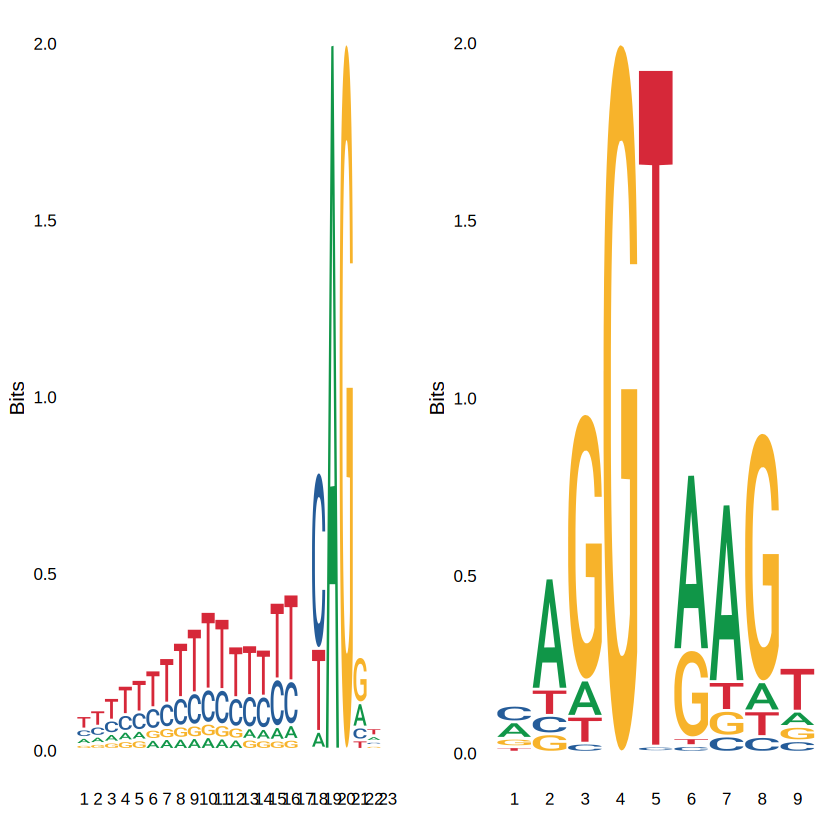

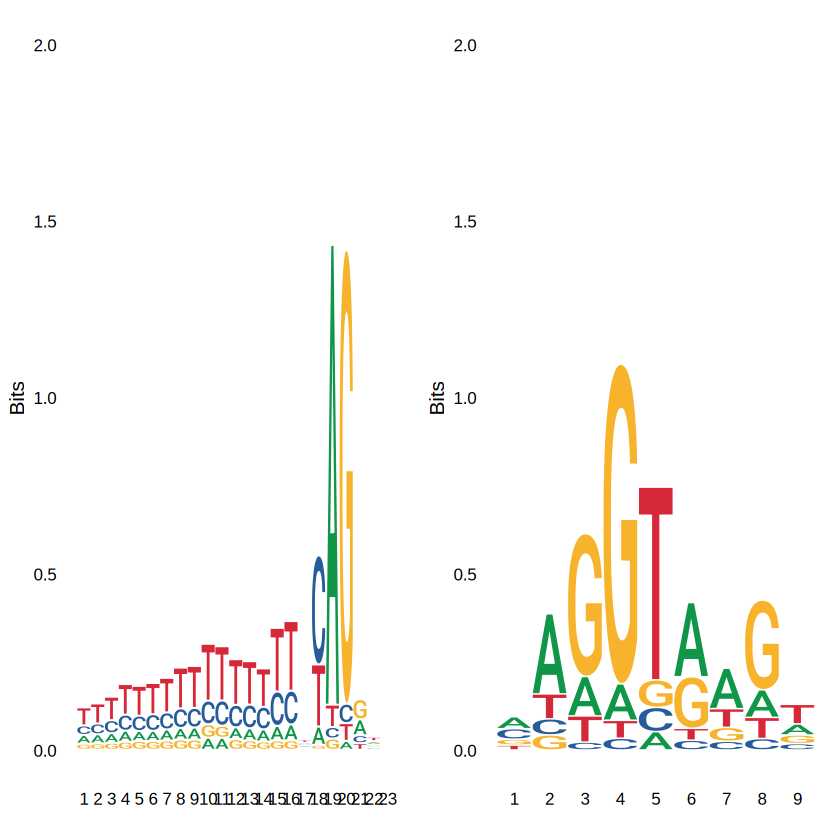

In [ ]:
library(ggseqlogo)
index_offset_table <- psi_table_pivot %>% 
  select(index_offset) %>% 
  separate(index_offset, into = c("ID", "offset"), sep = "__", remove = F) %>%
  separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":", remove = F) %>% 
  mutate(upstream_offset = as.integer(upstream_offset)) %>%
  mutate(downstream_offset = as.integer(downstream_offset)) %>%
  mutate(const_offset = as.integer(const_offset)) %>%
  mutate(librarySequence = chartr("T", "U", librarySequence))


twist_barcodes <- read_csv("/mnt/dawnccle2/melange/data/guide_library/20230130_twist_library_v3.csv") %>%
  mutate(barcodeRevcomp = sapply(barcode, reverse_complement))

index_offset_table <- index_offset_table %>% 
  left_join(twist_barcodes, by = c("ID" ))

# Adjust the sequences upstreamIntronSeq, skippedExonSeq, downstreamIntronSeq based on offset.
index_offset_table <- index_offset_table %>%
  mutate(upstreamIntron_len = nchar(upstreamIntronSeq)) %>%
  mutate(downstreamIntron_len = nchar(downstreamIntronSeq)) %>%
  mutate(skippedExon_len = nchar(skippedExonSeq)) %>%
  mutate(upstreamIntron_len_adj = upstreamIntron_len + upstream_offset) %>%
  mutate(downstreamIntron_len_adj = downstreamIntron_len - downstream_offset) %>%
  mutate(skippedExon_len_adj = skippedExon_len - upstream_offset + downstream_offset) %>%
  mutate(upstreamIntronSeq_adj = substr(librarySequence, 1, upstreamIntron_len_adj)) %>%
  mutate(skippedExonSeq_adj = substr(librarySequence, upstreamIntron_len_adj + 1, upstreamIntron_len_adj + skippedExon_len_adj)) %>%
  mutate(downstreamIntronSeq_adj = substr(librarySequence, upstreamIntron_len_adj + skippedExon_len_adj + 1, upstreamIntron_len_adj + skippedExon_len_adj + downstreamIntron_len_adj))


# Reference offset only.
ref_offset <- index_offset_table %>% 
  filter(offset == "0:0:0")
# Function to safely extract substrings
safe_substr <- function(seq, start, stop) {
  ifelse(nchar(seq) >= stop, substr(seq, start, stop), NA)
}

# Extract Upstream Splice Site Motif (Last 20 bp of Upstream Intron + First 10 bp of Skipped Exon)
ref_offset <- ref_offset %>%
  mutate(
    upstream_motif = paste0(
      safe_substr(upstreamIntronSeq_adj, nchar(upstreamIntronSeq_adj) - 19, nchar(upstreamIntronSeq_adj)),
      safe_substr(skippedExonSeq_adj, 1, 3)
    )
  )

# Extract Downstream Splice Site Motif (Last 10 bp of Skipped Exon + First 20 bp of Downstream Intron)
ref_offset <- ref_offset %>%
  mutate(
    downstream_motif = paste0(
      safe_substr(skippedExonSeq_adj, nchar(skippedExonSeq_adj) - 2, nchar(skippedExonSeq_adj)),
      safe_substr(downstreamIntronSeq_adj, 1, 6)
    )
  )

# Remove any NA values
ref_offset <- ref_offset %>%
  filter(!is.na(upstream_motif) & !is.na(downstream_motif))

# Plot Upstream Splice Site Motif Logo
p_upstream <- ggseqlogo(ref_offset$upstream_motif, method = "bits") 
p_downstream <- ggseqlogo(ref_offset$downstream_motif, method = "bits")

# Save the plots
p <- gridExtra::grid.arrange(p_upstream, p_downstream, ncol = 2)
ggsave(filename = paste0(output_filepath, "/figS02_splice_site_motif_ref_logo.pdf"), 
       plot = p, 
       width = 12, height = 3, dpi = 300)


# Plot for non-ref
non_ref_offset <- index_offset_table %>% 
  filter(offset != "0:0:0")

# Extract Upstream Splice Site Motif (Last 20 bp of Upstream Intron + First 10 bp of Skipped Exon)
non_ref_offset <- non_ref_offset %>%
  mutate(
    upstream_motif = paste0(
      safe_substr(upstreamIntronSeq_adj, nchar(upstreamIntronSeq_adj) - 19, nchar(upstreamIntronSeq_adj)),
      safe_substr(skippedExonSeq_adj, 1, 3)
    )
  )

# Extract Downstream Splice Site Motif (Last 10 bp of Skipped Exon + First 20 bp of Downstream Intron)
non_ref_offset <- non_ref_offset %>%
  mutate(
    downstream_motif = paste0(
      safe_substr(skippedExonSeq_adj, nchar(skippedExonSeq_adj) - 2, nchar(skippedExonSeq_adj)),
      safe_substr(downstreamIntronSeq_adj, 1, 6)
    )
  )

# Remove any NA values
non_ref_offset <- non_ref_offset %>%
  filter(!is.na(upstream_motif) & !is.na(downstream_motif)) %>% 
  filter(nchar(upstream_motif) == 23 & nchar(downstream_motif) == 9)

# Plot Upstream Splice Site Motif Logo
p_upstream <- ggseqlogo(non_ref_offset$upstream_motif, method = "bits") + ylim(0,2)
p_downstream <- ggseqlogo(non_ref_offset$downstream_motif, method = "bits") + ylim(0,2)
p <- gridExtra::grid.arrange(p_upstream, p_downstream, ncol = 2)
ggsave(filename = paste0(output_filepath, "/figS02_splice_site_motif_non_ref_logo.pdf"), 
       plot = p, 
       width = 12, height = 3, dpi = 300)
